In [14]:
import matplotlib.pylab as plt
import numpy as np
import matplotlib.animation as animation

def TL(t):
  T = 10.0
  return T

def TR(t):
  T = 10.0 + 2.5*np.sin(4*np.pi*t)
  return T

def CondicionInicial(x):

  caso = 1
  if caso == 1:
    T = 10.0

  return T

def main():

  xL = 0.0
  xR = 1.0

  N = 20
  dx = (xR-xL)/(N-1)

  T    = np.zeros(N)
  Tnew = np.zeros(N)
  x    = np.linspace(xL,xR,N)

  time = 0.0
  tfin = 1.0

  k = 1.0
  rho = 10.0
  Cp = 1.0
  alpha = k/(rho*Cp)

  dt = 0.1
  CFL = dt*alpha/(dx**2)
  print('CFL = ',CFL)

  it = 0

  for i in range(N):
    T[i] = CondicionInicial(x[i])

  a = alpha*dt/(dx**2)
  A = np.zeros((N,N))
  b = np.zeros((N,1))
  for i in range(N):
    if i == 0:
      A[i,i] = 1.0
    elif i == N-1:
      A[i,i] = 1.0
    else:
      A[i,i-1] = -a
      A[i,i] = 1.0 + 2*a
      A[i,i+1] = -a


  # List to store temperature profiles for animation
  T_profiles = []
  times = []

  # Store initial state
  T_profiles.append(T.copy())
  times.append(time)

  while time < tfin:
    if time + dt > tfin:
      dt = tfin - time

    # Build right hand side
    for i in range(N):
      if i == 0:
        b[i] = TL(time)
      elif i == N-1:
        b[i] = TR(time)
      else:
        b[i] = T[i]

    # Solve Ax = b
    Tnew = np.linalg.solve(A, b)

    T = Tnew.copy()
    time = time + dt
    it = it + 1

    T_profiles.append(T.copy())
    times.append(time)

  fig, ax = plt.subplots(figsize=(10, 6))
  line, = ax.plot(x, T_profiles[0])
  ax.set_xlabel('x')
  ax.set_ylabel('T °C')
  ax.set_ylim(5.0, 15.0)
  ax.set_title('Evolución temporal de la temperatura')
  ax.grid(True, linestyle='--', alpha=0.7)

  def update(frame):
    line.set_ydata(T_profiles[frame])
    ax.set_title(f'Evolución temporal de la temperatura | Time = {times[frame]:.4f} s')
    return line,

  ani = animation.FuncAnimation(
      fig,
      update,
      frames=len(T_profiles),
      interval=100,  # Milliseconds per frame
      blit=True
  )

  # To save the animation, you will need ffmpeg or imagemagick installed
  # For Colab, usually imagemagick is available for GIF.
  # If you prefer MP4, you might need to install ffmpeg: !apt-get update && apt-get install ffmpeg
  ani.save('difusion_calor.gif', writer='pillow', fps=10)
  plt.close(fig) # Close the plot to prevent it from showing before the GIF is generated
  print('Animation saved as difusion_calor.gif')

  return x,T,time,it

x,T,time,it = main()


CFL =  3.610000000000001
Animation saved as difusion_calor.gif


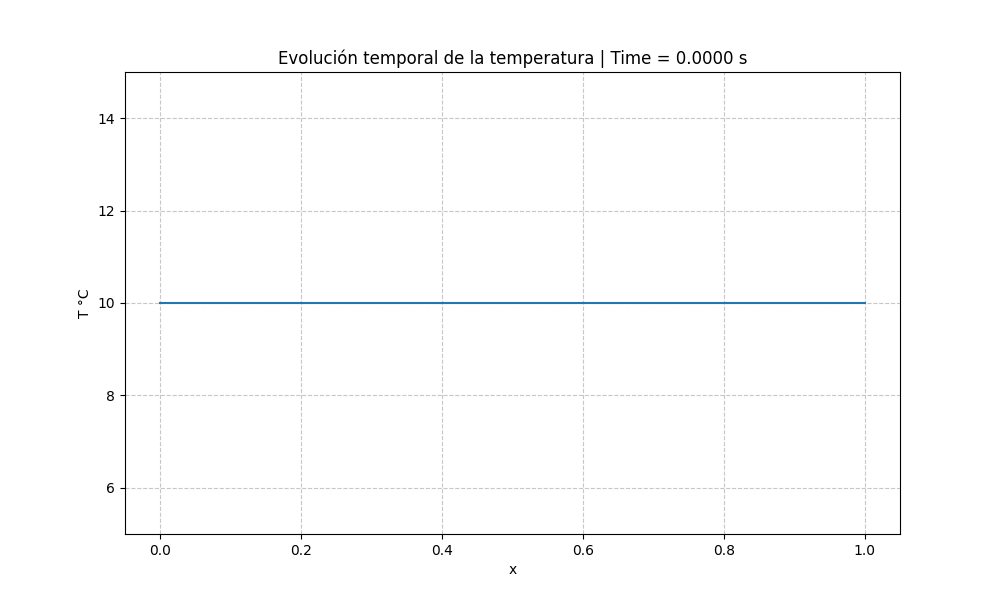

In [12]:
from IPython.display import Image
Image(open('difusion_calor.gif','rb').read())

Text(0.5, 1.0, ' Time = 1.0000 s')

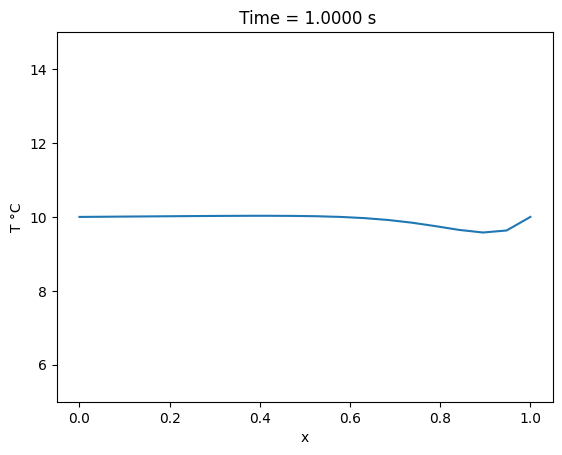

In [13]:
fig = plt.figure('Solución final')
plt.clf()
plt.plot(x,T)
plt.ylim(5.0,15.0)
plt.xlabel('x')
plt.ylabel('T °C')
plt.title(' Time = {:0.4f} s'.format(time))